# Task 2.2.1: Introduction to Deep Learning-Based Object Detection
## Definition and purpose of deep learning-based object detection in computer vision

In [1]:
# Importing required libraries, which include:
# OpenCV library used for the many tasks in computer vision, from loading images, to processing, detecting, shapes, tracking objects etc.:
import cv2
# Numpy is very useful computation library, here we can use it to compute means:
import numpy as np
# We need the following to show images as plots (x and y axes), later we will use it to draw actual plots too:
import matplotlib.pyplot as plt

# We need the following to draw areas of interest on our plots and images:
import matplotlib.patches as patches

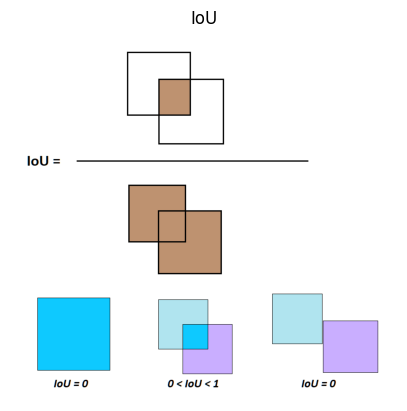

In [ ]:
# Load the input image
image = cv2.imread("data/iou.png")

# Display the output image
plt.imshow(image)
plt.title("IoU")
plt.axis("off")
plt.show()

Task 1 - Calculating Intersection over Union

Take a picture with your webcam and draw two rectangles on it - bounding boxes representing a ground truth of your detected face along with a "prediction" bounding box, manually entered for the purposes of this example, and calculate and display the IoU value.

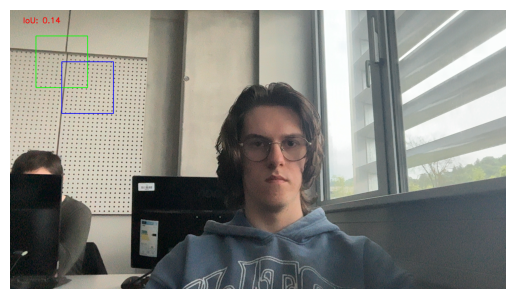

IoU value: 0.14


In [7]:

def calculate_iou(boxA, boxB):
    """
    Calculate Intersection over Union between two boxes.

    box format: (x1, y1, x2, y2)
    """

    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    intersection_width = max(0, xB - xA)
    intersection_height = max(0, yB - yA)

    intersection_area = intersection_width * intersection_height

    boxA_area = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxB_area = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    union_area = boxA_area + boxB_area - intersection_area

    if union_area == 0:
        return 0

    iou = intersection_area / union_area

    return iou


# Capture image with webcam
cap = cv2.VideoCapture(0)

ret, image = cap.read()

cap.release()


# Draw two overlapping rectangles on image
box1 = (100, 100, 300, 300)
box2 = (200, 200, 400, 400)

iou = calculate_iou(box1, box2)

cv2.rectangle(image, (box1[0], box1[1]), (box1[2], box1[3]), (0, 255, 0), 2)
cv2.rectangle(image, (box2[0], box2[1]), (box2[2], box2[3]), (255, 0, 0), 2)

cv2.putText(
    image,
    f"IoU: {iou:.2f}",
    (50, 50),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 0, 255),
    2
)

# Show image
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

print(f"IoU value: {iou:.2f}")

# Bonus: Allow the user to select rectangles on the image

To finish todays introduction lets take a look at a Deep Learning-based Object Detection algorithm in action.

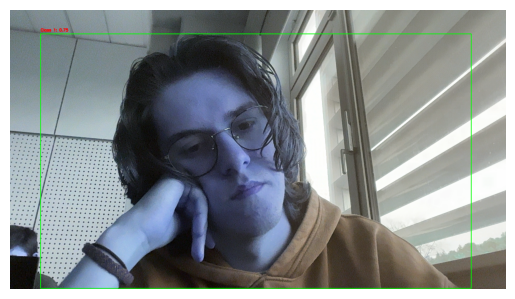

: 

In [2]:
import tensorflow as tf
import tensorflow_hub as hub

# Load the pre-trained model from TensorFlow Hub
model_url = "https://tfhub.dev/tensorflow/ssd_mobilenet_v2/2"
detector = hub.load(model_url)

def detect_objects(img):
    # Convert the BGR image to RGB and process
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    input_tensor = tf.convert_to_tensor([rgb], dtype=tf.uint8)
    detections = detector(input_tensor)


    # Extract detection boxes, classes, and scores
    boxes = detections["detection_boxes"][0].numpy()
    classes = detections["detection_classes"][0].numpy().astype(int)
    scores = detections["detection_scores"][0].numpy()

    return boxes, classes, scores

# Capture image from webcam
cap = cv2.VideoCapture(0)
ret, image = cap.read()
cap.release()

boxes, classes, scores = detect_objects(image)

# Threshold for detection
threshold = 0.5

height, width, _ = image.shape
for box, cls, score in zip(boxes, classes, scores):
    if score > threshold:
        y1, x1, y2, x2 = box
        y1, x1, y2, x2 = int(y1 * height), int(x1 * width), int(y2 * height), int(x2 * width)
        label = f"Class {cls}: {score:.2f}"
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

cv2.imshow("Detections", image)
cv2.waitKey(0)
cv2.destroyAllWindows()

plt.figure()
plt.imshow(image)
plt.axis("off")
plt.show()